In [9]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = '/content/drive/MyDrive/Swahili_Audio_Project'
for sub in ['results', 'models', 'submissions']:
    os.makedirs(f'{BASE}/{sub}', exist_ok=True)
print("Base dir ready:", BASE)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Base dir ready: /content/drive/MyDrive/Swahili_Audio_Project


In [24]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers
from tensorflow.keras.utils import to_categorical

In [10]:
ZIP_PATH = '/content/w1.5_energy_mfcc40_d.zip'
print("Exists:", os.path.exists(ZIP_PATH))
print("Size (MB):", round(os.path.getsize(ZIP_PATH) / 1e6, 2))

Exists: True
Size (MB): 277.49


In [11]:
import zipfile, time, os

EXTRACT_DIR = '/content/dataset'
os.makedirs(EXTRACT_DIR, exist_ok=True)

t0 = time.time()
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_DIR)
print(f"Extracted in {time.time()-t0:.1f}s")

Extracted in 4.1s


In [26]:
DATA_DIR = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    if 'train.npz' in files:
        DATA_DIR = root
        break

assert DATA_DIR is not None, "train.npz not found"
print("DATA_DIR =", DATA_DIR)

DATA_DIR = /content/dataset/w1.5_energy_mfcc40_d


In [27]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (accuracy_score, f1_score,
                             classification_report, confusion_matrix)

# Labels
with open(os.path.join(DATA_DIR, 'labels.json')) as f:
    LABELS = json.load(f)
idx_to_label = {v: k for k, v in LABELS.items()}
CLASS_NAMES  = [idx_to_label[i] for i in range(len(LABELS))]
NUM_CLASSES  = len(CLASS_NAMES)
print("Class order:", CLASS_NAMES)

# npz files
train_npz = np.load(os.path.join(DATA_DIR, 'train.npz'), allow_pickle=True)
val_npz   = np.load(os.path.join(DATA_DIR, 'val.npz'),   allow_pickle=True)
test_npz  = np.load(os.path.join(DATA_DIR, 'test.npz'),  allow_pickle=True)

X_train = train_npz['X']   # (2940, 151, 120)
y_train = train_npz['y']   # (2940,)
X_val   = val_npz['X']
y_val   = val_npz['y']
X_test  = test_npz['X']
test_ids = test_npz['ids']  # Word_ids for submission

TIMESTEPS  = X_train.shape[1]   # 151
N_FEATURES = X_train.shape[2]   # 120

print(f"\nX_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape},   y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}")
print(f"TIMESTEPS={TIMESTEPS}, N_FEATURES={N_FEATURES}, CLASSES={NUM_CLASSES}")

Class order: ['hapana', 'kumi', 'mbili', 'moja', 'nane', 'ndio', 'nne', 'saba', 'sita', 'tano', 'tatu', 'tisa']

X_train: (2940, 151, 120), y_train: (2940,)
X_val  : (630, 151, 120),   y_val  : (630,)
X_test : (630, 151, 120)
TIMESTEPS=151, N_FEATURES=120, CLASSES=12


In [28]:
mean = X_train.mean()
std  = X_train.std()

X_train = ((X_train - mean) / (std + 1e-8)).astype(np.float32)
X_val   = ((X_val   - mean) / (std + 1e-8)).astype(np.float32)
X_test  = ((X_test  - mean) / (std + 1e-8)).astype(np.float32)

print("Post-norm mean/std:", X_train.mean().round(4), X_train.std().round(4))

Post-norm mean/std: 0.0 1.0


In [16]:
def to_seq_format(X, feat_candidates=(40, 41, 120)): # Added 120 to feat_candidates
    F = X.shape[-1]
    if F in feat_candidates:
        print(f"Already (N, T, F) with F={F}: {X.shape}")
        return X
    # look for the feature axis elsewhere
    for axis in [1, 2]:
        if X.shape[axis] in feat_candidates:
            X = np.transpose(X, (0, 2, 1)) if axis == 1 else X
            print(f"Reordered axis {axis} -> (N, T, F): {X.shape}")
            return X
    raise ValueError(f"Cannot locate feature axis in {X.shape}")

X_train = to_seq_format(X_train)
X_val   = to_seq_format(X_val)
X_test  = to_seq_format(X_test)

TIMESTEPS  = X_train.shape[1]
N_FEATURES = X_train.shape[2]
print(f"\nTIMESTEPS = {TIMESTEPS}, N_FEATURES = {N_FEATURES}")

Already (N, T, F) with F=120: (2940, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)
Already (N, T, F) with F=120: (630, 151, 120)

TIMESTEPS = 151, N_FEATURES = 120


In [17]:
mean = X_train.mean()
std  = X_train.std()

X_train = ((X_train - mean) / (std + 1e-8)).astype(np.float32)
X_val   = ((X_val   - mean) / (std + 1e-8)).astype(np.float32)
X_test  = ((X_test  - mean) / (std + 1e-8)).astype(np.float32)
print("Post-norm train mean/std:", X_train.mean().round(4), X_train.std().round(4))

Post-norm train mean/std: 0.0 1.0


In [30]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

y_train_oh = to_categorical(y_train, NUM_CLASSES)
y_val_oh   = to_categorical(y_val,   NUM_CLASSES)

print("y_train_oh:", y_train_oh.shape, "| y_val_oh:", y_val_oh.shape)
print("TF:", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

y_train_oh: (2940, 12) | y_val_oh: (630, 12)
TF: 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [33]:
class SpecAugment(tf.keras.layers.Layer):
    """Randomly masks frequency and time strips during training only."""
    def __init__(self, freq_mask=8, time_mask=10, n_masks=2, **kwargs):
        super().__init__(**kwargs)
        self.freq_mask = freq_mask
        self.time_mask = time_mask
        self.n_masks   = n_masks

    def call(self, x, training=False):
        if not training:
            return x

        shape = tf.shape(x)
        B, T, F = shape[0], shape[1], shape[2]

        # Frequency masking
        for _ in range(self.n_masks):
            f  = tf.random.uniform([], 0, self.freq_mask, dtype=tf.int32)
            f0 = tf.random.uniform([], 0, F - f, dtype=tf.int32)
            mask = tf.concat([
                tf.ones([B, T, f0], dtype=x.dtype),
                tf.zeros([B, T, f], dtype=x.dtype),
                tf.ones([B, T, F - f0 - f], dtype=x.dtype),
            ], axis=2)
            x = x * mask

        # Time masking
        for _ in range(self.n_masks):
            t  = tf.random.uniform([], 0, self.time_mask, dtype=tf.int32)
            t0 = tf.random.uniform([], 0, T - t, dtype=tf.int32)
            mask = tf.concat([
                tf.ones([B, t0, F], dtype=x.dtype),
                tf.zeros([B, t, F], dtype=x.dtype),
                tf.ones([B, T - t0 - t, F], dtype=x.dtype),
            ], axis=1)
            x = x * mask

        return x

    def get_config(self):
        cfg = super().get_config()
        cfg.update({'freq_mask': self.freq_mask,
                    'time_mask': self.time_mask,
                    'n_masks':   self.n_masks})
        return cfg

# Sanity check
_test = tf.random.normal((2, 151, 120))
_out  = SpecAugment()(_test, training=True)
print("SpecAugment OK — in:", _test.shape, "out:", _out.shape)

SpecAugment OK — in: (2, 151, 120) out: (2, 151, 120)


In [34]:
from tensorflow.keras import layers, models, callbacks, optimizers, regularizers

def build_bigru(T, F, C,
                gru1=96, gru2=48,
                dropout=0.5, l2=1e-4, input_noise=0.01, lr=1e-3):
    reg = regularizers.l2(l2)

    inp = layers.Input(shape=(T, F), name='input')

    # Augmentation
    x = layers.GaussianNoise(input_noise)(inp)
    x = SpecAugment(freq_mask=8, time_mask=10, n_masks=2, name='specaug')(x)

    # BiGRU stack
    x = layers.Bidirectional(
        layers.GRU(gru1, return_sequences=True, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Bidirectional(
        layers.GRU(gru2, kernel_regularizer=reg)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    # Classifier head
    x = layers.Dense(64, activation='relu', kernel_regularizer=reg)(x)
    x = layers.Dropout(dropout * 0.6)(x)
    out = layers.Dense(C, activation='softmax')(x)

    m = models.Model(inp, out)
    m.compile(optimizer=optimizers.Adam(lr),
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m

model = build_bigru(TIMESTEPS, N_FEATURES, NUM_CLASSES)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gaussian_noise_1                │ (None, 151, 120)       │             0 │
│ (GaussianNoise)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ specaug (SpecAugment)           │ (None, 151, 120)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 151, 192)       │       125,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 151, 192)       │           768 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 151, 192)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 96)             │        69,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 96)             │           384 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 12)             │           780 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 203,404 (794.55 KB)

 Trainable params: 202,828 (792.30 KB)

 Non-trainable params: 576 (2.25 KB)

In [35]:
CKPT = f'{BASE}/models/best_bigru_mfcc.keras'

cbs = [
    callbacks.ModelCheckpoint(CKPT, monitor='val_accuracy',
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor='val_accuracy', patience=12,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train_oh,
    validation_data=(X_val, y_val_oh),
    epochs=80,
    batch_size=64,
    callbacks=cbs,
    verbose=1,
)

Epoch 1/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.0954 - loss: 3.4503
Epoch 1: val_accuracy improved from None to 0.07937, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_bigru_mfcc.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_bigru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 6s 58ms/step - accuracy: 0.0925 - loss: 3.3055 - val_accuracy: 0.0794 - val_loss: 2.5673 - learning_rate: 0.0010
Epoch 2/80
45/46 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.1035 - loss: 3.0430
Epoch 2: val_accuracy improved from 0.07937 to 0.09841, saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_bigru_mfcc.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Swahili_Audio_Project/models/best_bigru_mfcc.keras
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.1044 - loss: 3.0023 - val_accuracy: 0.0984 - val_loss: 2.5234 - learning_rate: 0.0010
Epoch 3/80
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 37

Val Accuracy: 0.9397
Val Macro-F1: 0.9394

              precision    recall  f1-score   support

      hapana       0.95      1.00      0.97        53
        kumi       0.96      0.92      0.94        52
       mbili       0.91      0.94      0.93        53
        moja       0.94      0.96      0.95        52
        nane       0.98      0.88      0.93        52
        ndio       0.94      0.94      0.94        53
         nne       0.90      0.88      0.89        52
        saba       0.93      1.00      0.96        52
        sita       0.94      0.96      0.95        53
        tano       0.98      0.89      0.93        53
        tatu       0.93      0.94      0.93        53
        tisa       0.92      0.94      0.93        52

    accuracy                           0.94       630
   macro avg       0.94      0.94      0.94       630
weighted avg       0.94      0.94      0.94       630



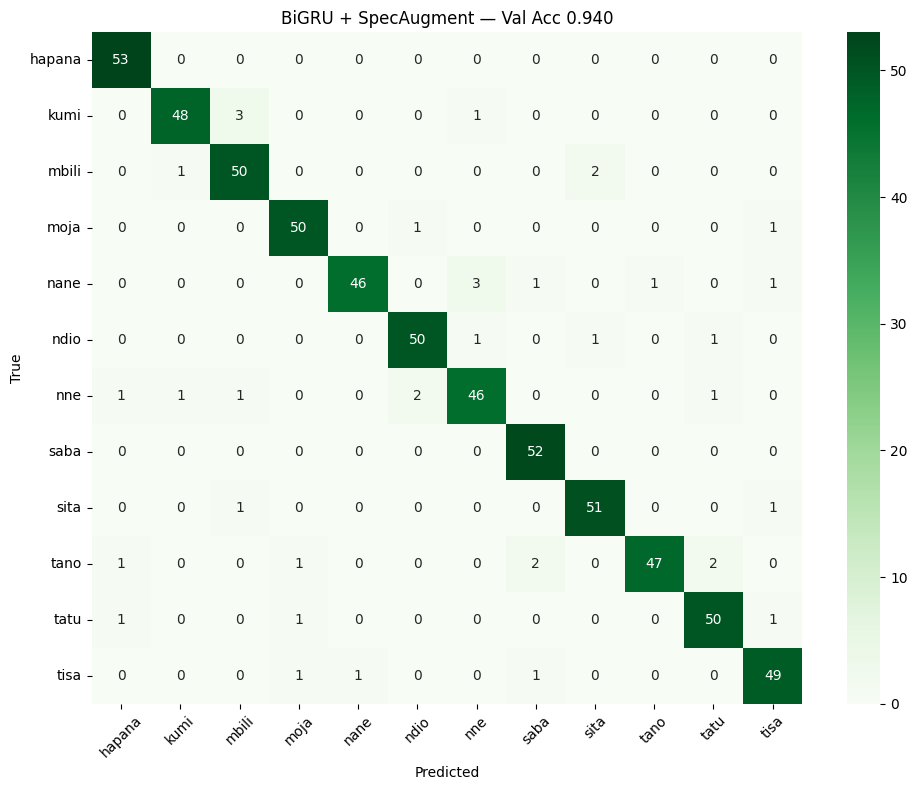

In [36]:
y_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
acc = accuracy_score(y_val, y_pred)
f1  = f1_score(y_val, y_pred, average='macro')

print(f"Val Accuracy: {acc:.4f}")
print(f"Val Macro-F1: {f1:.4f}\n")
print(classification_report(y_val, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title(f'BiGRU + SpecAugment — Val Acc {acc:.3f}')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{BASE}/results/bigru_mfcc_confusion.png', dpi=150)
plt.show()

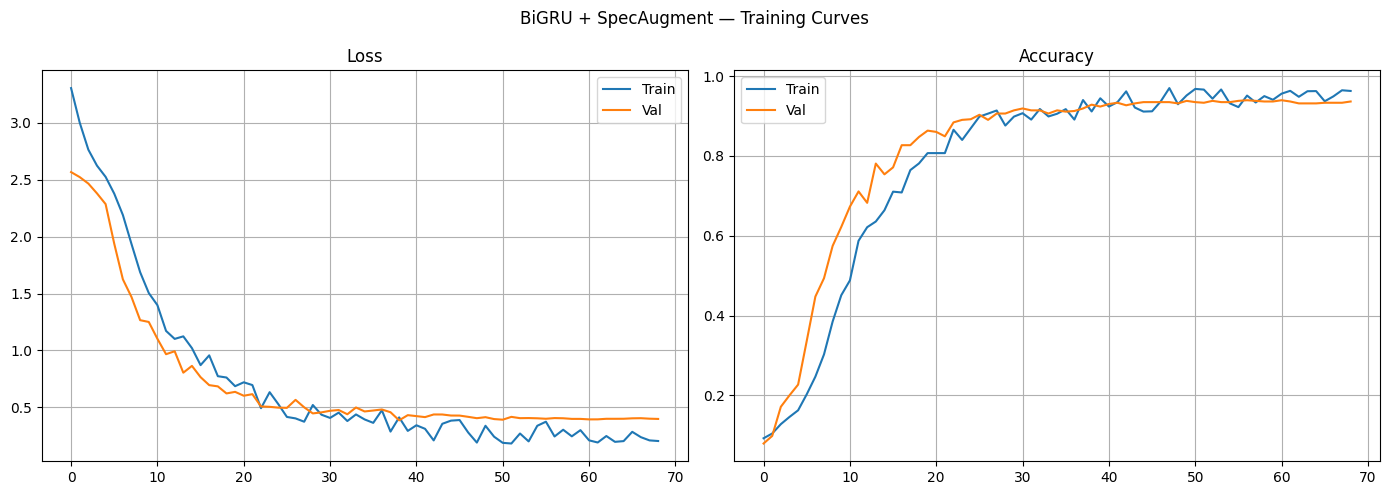

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True)

plt.suptitle('BiGRU + SpecAugment — Training Curves')
plt.tight_layout()
plt.savefig(f'{BASE}/results/bigru_mfcc_learning_curves.png', dpi=150)
plt.show()

In [38]:
pd.DataFrame([{
    'model': 'BiGRU + SpecAug (MFCC-40)',
    'val_accuracy': acc,
    'val_macro_f1': f1,
    'epochs_trained': len(history.history['loss']),
    'params': model.count_params(),
}]).to_csv(f'{BASE}/results/bigru_mfcc_results.csv', index=False)
print("Saved results.")

Saved results.


In [39]:
test_probs = model.predict(X_test, verbose=0)
print("Test probs shape:", test_probs.shape)

sub = pd.DataFrame({'Word_id': test_ids})
for j, c in enumerate(CLASS_NAMES):
    sub[c] = test_probs[:, j]

print(sub.head())
print("Row sums:", sub[CLASS_NAMES].sum(axis=1).describe().round(4))

sub.to_csv(f'{BASE}/submissions/bigru_mfcc_submission.csv', index=False)
print("Saved submission.")

Test probs shape: (630, 12)
               Word_id        hapana          kumi         mbili  \
0  id_v8rz06e6rv31.wav  2.206189e-07  1.140361e-04  9.996936e-01   
1  id_twhce0u5wcg0.wav  9.998336e-01  1.768826e-05  5.745145e-08   
2  id_3komqnffiaet.wav  7.535338e-05  5.572352e-07  9.393969e-08   
3  id_lbhxpmz7zdxl.wav  1.539935e-06  6.196736e-08  6.459253e-07   
4  id_giv6yxiwwxsw.wav  6.129739e-02  1.410167e-04  5.154114e-04   

           moja      nane          ndio           nne          saba  \
0  2.379218e-08  0.000005  2.216884e-05  1.569366e-04  1.115472e-09   
1  9.393596e-05  0.000002  3.505950e-06  4.170520e-08  4.824915e-07   
2  9.997994e-01  0.000042  1.985817e-05  5.016330e-05  7.861301e-06   
3  1.213645e-05  0.999831  6.177829e-08  9.494887e-05  2.733132e-07   
4  1.095429e-01  0.750322  2.415302e-03  2.127058e-03  2.997839e-03   

           sita          tano          tatu          tisa  
0  1.209325e-06  1.526733e-08  2.842673e-08  6.430578e-06  
1  8.489425e-09 